In [1]:
import warnings
warnings.filterwarnings("ignore")

## Market Basket Analysis

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("market_baskets_data.csv")

In [4]:
df.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7501 entries, 0 to 7500
Data columns (total 20 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       7501 non-null   object
 1   1       5747 non-null   object
 2   2       4389 non-null   object
 3   3       3345 non-null   object
 4   4       2529 non-null   object
 5   5       1864 non-null   object
 6   6       1369 non-null   object
 7   7       981 non-null    object
 8   8       654 non-null    object
 9   9       395 non-null    object
 10  10      256 non-null    object
 11  11      154 non-null    object
 12  12      87 non-null     object
 13  13      47 non-null     object
 14  14      25 non-null     object
 15  15      8 non-null      object
 16  16      4 non-null      object
 17  17      4 non-null      object
 18  18      3 non-null      object
 19  19      1 non-null      object
dtypes: object(20)
memory usage: 1.1+ MB


In [6]:
df.isna().sum().reset_index()

,index,0
0,0,0
1,1,1754
2,2,3112
3,3,4156
4,4,4972
5,5,5637
6,6,6132
7,7,6520
8,8,6847
9,9,7106


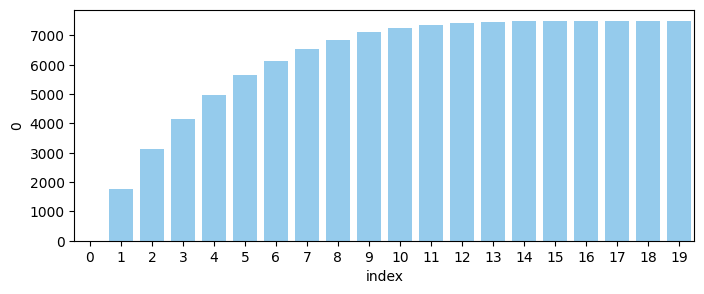

In [7]:
# Seeing Null values
ax, fig = plt.subplots(1,1, figsize=(8,3))
sns.barplot(df.isna().sum().reset_index(), x='index', y=0, color='lightskyblue')
plt.show()

Replacing NaN with 'unknown'

In [8]:
df.fillna('unkown', inplace=True)

Prepping Basket for Apriori Alogrithm

In [9]:
basket = list()
for i in range(df.shape[0]):
    cart = list()
    for j in range(df.shape[1]):
        item = df.iloc[i,j]
        if item != 'unkown':
            cart.append(item)
    basket.append(cart)

Apriori Alogrithm

In [10]:
from apyori import apriori

In [11]:
support = 0.01 # minimum threshold
confidence = 0.25 # minimum threshold: 25%
lift = 2 # minimum threshold:
length = 2 # minimum threshold: atleast two products in the rules

In [12]:
association_rules = apriori(basket, min_support=support, min_confidene = confidence, min_lift = lift, min_length = length)
association_results = list(association_rules)

In [13]:
cols = ['rule', 'support', 'items_base', 'items_add', 'confidence', 'lift']
rules = pd.DataFrame(columns=cols)

In [14]:
for relation_record in association_results:
    # Rule
    rule = list(relation_record[0])
    # Support
    support = relation_record[1]
    
    # Ordered Statistic
    for item in relation_record[2]:
        # Items Base
        items_base = list(item[0])
        # Items Add
        items_add = list(item[1])
        # Confidence
        confidence = item[2]
        # Lift
        lift = item[3]
        row = [rule, support, items_base, items_add, confidence, lift]
        df = pd.DataFrame(data=[row], columns=cols)
        rules = pd.concat([rules, df], ignore_index=True)

In [15]:
rules

,rule,support,items_base,items_add,confidence,lift
0,"[grated cheese, frozen pizza]",0.011332,[frozen pizza],[grated cheese],0.115332,2.201294
1,"[grated cheese, frozen pizza]",0.011332,[grated cheese],[frozen pizza],0.216285,2.201294
2,"[herb & pepper, frozen pizza]",0.015998,[frozen pizza],[herb & pepper],0.162822,3.291994
3,"[herb & pepper, frozen pizza]",0.015998,[herb & pepper],[frozen pizza],0.323450,3.291994
4,"[olive oil, frozen pizza]",0.014131,[frozen pizza],[olive oil],0.143826,2.183889
5,"[olive oil, frozen pizza]",0.014131,[olive oil],[frozen pizza],0.214575,2.183889
6,"[spaghetti, frozen pizza]",0.039195,[frozen pizza],[spaghetti],0.398915,2.291162
7,"[spaghetti, frozen pizza]",0.039195,[spaghetti],[frozen pizza],0.225115,2.291162
8,"[shrimp, frozen vegetables]",0.016664,[frozen vegetables],[shrimp],0.174825,2.446574
9,"[shrimp, frozen vegetables]",0.016664,[shrimp],[frozen vegetables],0.233209,2.446574
